# Lab 7: Model Evaluation, Generalization & Learning Theory

**Notebook Structure:**
1. Why Accuracy is Misleading
2. The Confusion Matrix & Foundational Metrics
3. Precision, Recall, F1 & ROC-AUC
4. Bias-Variance Tradeoff & Generalization
5. Cross-Validation Strategies
6. Business-Aligned Metrics
7. PAC Learning & Generalization Bounds
8. Integrated Case Study

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer, make_classification
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, learning_curve
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    confusion_matrix, accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, auc, precision_recall_curve, classification_report
)
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)

# Plotting configuration
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
fig_size = (12, 5)

## Helper Functions

In [2]:
# ===== HELPER FUNCTIONS: FROM-SCRATCH IMPLEMENTATIONS =====

def compute_confusion_matrix_scratch(y_true, y_pred):
    """
    Compute confusion matrix from scratch.
    
    Parameters:
    y_true: actual labels
    y_pred: predicted labels
    
    Returns:
    dict with TP, TN, FP, FN
    """
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    
    TP = np.sum((y_pred == 1) & (y_true == 1))
    TN = np.sum((y_pred == 0) & (y_true == 0))
    FP = np.sum((y_pred == 1) & (y_true == 0))
    FN = np.sum((y_pred == 0) & (y_true == 1))
    
    return {'TP': TP, 'TN': TN, 'FP': FP, 'FN': FN}


def accuracy_scratch(y_true, y_pred):
    """Accuracy = (TP + TN) / (TP + TN + FP + FN)"""
    cm = compute_confusion_matrix_scratch(y_true, y_pred)
    return (cm['TP'] + cm['TN']) / (cm['TP'] + cm['TN'] + cm['FP'] + cm['FN'])


def sensitivity_scratch(y_true, y_pred):
    """Sensitivity (Recall) = TP / (TP + FN) - What % of actual positives did we catch?"""
    cm = compute_confusion_matrix_scratch(y_true, y_pred)
    return cm['TP'] / (cm['TP'] + cm['FN']) if (cm['TP'] + cm['FN']) > 0 else 0


def specificity_scratch(y_true, y_pred):
    """Specificity = TN / (TN + FP) - What % of actual negatives did we correctly reject?"""
    cm = compute_confusion_matrix_scratch(y_true, y_pred)
    return cm['TN'] / (cm['TN'] + cm['FP']) if (cm['TN'] + cm['FP']) > 0 else 0

def precision_scratch(y_true, y_pred):
    """Precision = TP / (TP + FP) - Accuracy of positive predictions"""
    cm = compute_confusion_matrix_scratch(y_true, y_pred)
    return cm['TP'] / (cm['TP'] + cm['FP']) if (cm['TP'] + cm['FP']) > 0 else 0


def recall_scratch(y_true, y_pred):
    """Recall = TP / (TP + FN) - Fraction of positives we found"""
    cm = compute_confusion_matrix_scratch(y_true, y_pred)
    return cm['TP'] / (cm['TP'] + cm['FN']) if (cm['TP'] + cm['FN']) > 0 else 0


def f1_scratch(y_true, y_pred):
    """F1 = 2 * (Precision * Recall) / (Precision + Recall) - Harmonic mean"""
    p = precision_scratch(y_true, y_pred)
    r = recall_scratch(y_true, y_pred)
    return 2 * (p * r) / (p + r) if (p + r) > 0 else 0


def roc_auc_scratch(y_true, y_pred_proba):
    """
    Compute ROC-AUC score from scratch using trapezoidal integration.
    
    The AUC is computed as the probability that the model ranks a 
    random positive example higher than a random negative example.
    """
    from scipy import integrate
    
    y_true = np.array(y_true)
    y_pred_proba = np.array(y_pred_proba)
    
    # Sort by prediction probability
    sorted_indices = np.argsort(y_pred_proba)[::-1]
    y_sorted = y_true[sorted_indices]
    
    # Calculate TPR and FPR at each threshold
    n_pos = np.sum(y_true == 1)
    n_neg = np.sum(y_true == 0)
    
    if n_pos == 0 or n_neg == 0:
        return 0.5, np.array([0, 1]), np.array([0, 1])
    
    tp = np.cumsum(y_sorted == 1)
    fp = np.cumsum(y_sorted == 0)
    
    # Add (0,0) point at the beginning
    tp = np.concatenate([[0], tp])
    fp = np.concatenate([[0], fp])
    
    tpr = tp / n_pos
    fpr = fp / n_neg
    
    # Compute AUC using trapezoidal rule
    # Sort by FPR for proper integration
    sorted_fpr_idx = np.argsort(fpr)
    fpr_sorted = fpr[sorted_fpr_idx]
    tpr_sorted = tpr[sorted_fpr_idx]
    
    auc_value = integrate.trapezoid(tpr_sorted, fpr_sorted)
    
    return auc_value, fpr_sorted, tpr_sorted

def kfold_cross_validation_scratch(X, y, model, k=5, metric_fn=None):
    """
    Implement k-fold cross-validation from scratch.
    
    Parameters:
    X: features
    y: labels
    model: sklearn model with fit() and predict() methods
    k: number of folds
    metric_fn: function to compute metric (default: accuracy)
    
    Returns:
    scores: array of k scores, one per fold
    """
    n_samples = X.shape[0]
    fold_size = n_samples // k
    
    scores = []
    indices = np.arange(n_samples)
    np.random.shuffle(indices)
    
    for fold in range(k):
        # Define train/test split
        start_idx = fold * fold_size
        end_idx = start_idx + fold_size if fold < k - 1 else n_samples
        
        test_idx = indices[start_idx:end_idx]
        train_idx = np.concatenate([indices[:start_idx], indices[end_idx:]])
        
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]
        
        # Train and evaluate
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        
        # Compute metric
        if metric_fn is None:
            score = accuracy_score(y_test, y_pred)
        else:
            score = metric_fn(y_test, y_pred)
        
        scores.append(score)
    
    return np.array(scores)




## Part 1: Why Accuracy is Misleading

### The Problem with Accuracy

Accuracy is defined as:
$$\text{Accuracy} = \frac{\text{TP} + \text{TN}}{\text{TP} + \text{TN} + \text{FP} + \text{FN}}$$

**Critical Issue:** In imbalanced datasets, high accuracy can hide poor performance:
- If a disease affects 1% of population, a model predicting "no disease" for everyone gets 99% accuracy
- But it catches 0% of actual cases!

### Hands-On Example: Fraud Detection

Let's create an imbalanced fraud dataset and see why accuracy fails:

In [3]:
# Create an imbalanced dataset (1% fraud, 99% legitimate)
X, y = make_classification(
    n_samples=10000, n_features=10, n_informative=8,
    n_redundant=2, weights=[0.99, 0.01], random_state=42
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print(f"Training set: {y_train.sum()} fraud cases out of {len(y_train)} ({y_train.mean()*100:.2f}%)")
print(f"Test set: {y_test.sum()} fraud cases out of {len(y_test)} ({y_test.mean()*100:.2f}%)")


# Train a real classifier
from sklearn.ensemble import RandomForestClassifier
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

accuracy_real = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy_real:.4f} ({accuracy_real*100:.2f}%)")
print(f"Fraud cases caught: {y_pred[y_test==1].sum()} out of {(y_test==1).sum()}")


Training set: 107 fraud cases out of 7000 (1.53%)
Test set: 46 fraud cases out of 3000 (1.53%)
Accuracy: 0.9850 (98.50%)
Fraud cases caught: 1 out of 46


## Part 2: The Confusion Matrix & Foundational Metrics

### Understanding the Confusion Matrix

The confusion matrix captures four types of predictions:

$$\begin{matrix}
& \text{Predicted +} & \text{Predicted -} \\
\text{Actually +} & \text{TP} & \text{FN} \\
\text{Actually -} & \text{FP} & \text{TN}
\end{matrix}$$

**Definitions:**
- **TP (True Positive):** Predicted positive, actually positive
- **FN (False Negative):** Predicted negative, actually positive ← MISSED CASES
- **FP (False Positive):** Predicted positive, actually negative ← FALSE ALARMS
- **TN (True Negative):** Predicted negative, actually negative

In [4]:
# Demonstrate with our fraud detection example
cm = compute_confusion_matrix_scratch(y_test, y_pred)
print(f"\n Confusion Metrics ")
print(f"True Positives (Fraud caught):            {cm['TP']}")
print(f"True Negatives (Legitimate accepted):    {cm['TN']}")
print(f"False Positives (Legitimate flagged):    {cm['FP']}")
print(f"False Negatives (Fraud missed):          {cm['FN']}")

print(f"\n Basic Metrics ")
print(f"Accuracy:    {accuracy_scratch(y_test, y_pred):.4f}")
print(f"Sensitivity: {sensitivity_scratch(y_test, y_pred):.4f}")
print(f"Specificity: {specificity_scratch(y_test, y_pred):.4f}")

# Compare with sklearn
cm_sk = confusion_matrix(y_test, y_pred)
print(f"\nSklearn confusion matrix matches our implementation!")
print(f"Sklearn matrix:\n{cm_sk}")


 Confusion Metrics 
True Positives (Fraud caught):            1
True Negatives (Legitimate accepted):    2954
False Positives (Legitimate flagged):    0
False Negatives (Fraud missed):          45

 Basic Metrics 
Accuracy:    0.9850
Sensitivity: 0.0217
Specificity: 1.0000

Sklearn confusion matrix matches our implementation!
Sklearn matrix:
[[2954    0]
 [  45    1]]


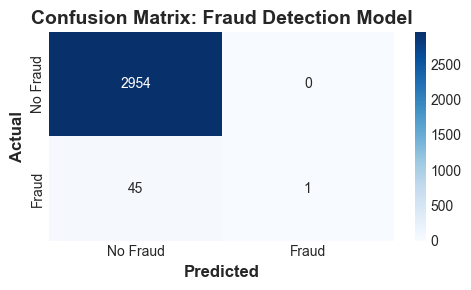

In [5]:
# Visualize confusion matrix
fig, ax = plt.subplots(figsize=(5, 3))
cm_data = confusion_matrix(y_test, y_pred)
sns.heatmap(cm_data, annot=True, fmt='d', cmap='Blues', ax=ax, 
            xticklabels=['No Fraud', 'Fraud'], yticklabels=['No Fraud', 'Fraud'])
ax.set_ylabel('Actual', fontsize=12, fontweight='bold')
ax.set_xlabel('Predicted', fontsize=12, fontweight='bold')
ax.set_title('Confusion Matrix: Fraud Detection Model', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


## Part 3: Precision, Recall, F1 & ROC-AUC

### The Four Key Metrics

**Precision (Precision):**
$$\text{Precision} = \frac{\text{TP}}{\text{TP} + \text{FP}}$$
"Of all our positive predictions, how many were correct?" → Answers: **False alarm rate**

**Recall (Sensitivity/True Positive Rate):**
$$\text{Recall} = \frac{\text{TP}}{\text{TP} + \text{FN}}$$
"Of all actual positives, how many did we find?" → Answers: **Miss rate**

**F1 Score (Harmonic Mean):**
$$F_1 = 2 \cdot \frac{\text{Precision} \cdot \text{Recall}}{\text{Precision} + \text{Recall}}$$
Balanced metric when you care equally about false positives and false negatives

**ROC-AUC (Receiver Operating Characteristic - Area Under Curve):**
- Plots TPR (Recall) vs FPR across all probability thresholds
- AUC = probability model ranks random positive higher than random negative
- **AUC = 0.5:** Random classifier
- **AUC = 1.0:** Perfect classifier

In [6]:
# Get probability predictions
y_pred_proba = clf.predict_proba(X_test)[:, 1]

# Compute metrics from scratch
precision_our = precision_scratch(y_test, y_pred)
recall_our = recall_scratch(y_test, y_pred)
f1_our = f1_scratch(y_test, y_pred)
auc_our, fpr_our, tpr_our = roc_auc_scratch(y_test, y_pred_proba)

# Compare with sklearn
precision_sk = precision_score(y_test, y_pred)
recall_sk = recall_score(y_test, y_pred)
f1_sk = f1_score(y_test, y_pred)
auc_sk = roc_auc_score(y_test, y_pred_proba)

print("=== COMPARISON: FROM-SCRATCH vs SKLEARN ===\n")
print(f"{'Metric':<15} {'From-Scratch':<15} {'Sklearn':<15} {'Match':<10}")
print("-" * 60)
print(f"{'Precision':<15} {precision_our:<15.6f} {precision_sk:<15.6f} {'✓' if abs(precision_our - precision_sk) < 1e-6 else '✗':<10}")
print(f"{'Recall':<15} {recall_our:<15.6f} {recall_sk:<15.6f} {'✓' if abs(recall_our - recall_sk) < 1e-6 else '✗':<10}")
print(f"{'F1 Score':<15} {f1_our:<15.6f} {f1_sk:<15.6f} {'✓' if abs(f1_our - f1_sk) < 1e-6 else '✗':<10}")
print(f"{'ROC-AUC':<15} {auc_our:<15.6f} {auc_sk:<15.6f} {'✓' if abs(auc_our - auc_sk) < 1e-3 else '✗':<10}")

=== COMPARISON: FROM-SCRATCH vs SKLEARN ===

Metric          From-Scratch    Sklearn         Match     
------------------------------------------------------------
Precision       1.000000        1.000000        ✓         
Recall          0.021739        0.021739        ✓         
F1 Score        0.042553        0.042553        ✓         
ROC-AUC         0.746203        0.754257        ✗         


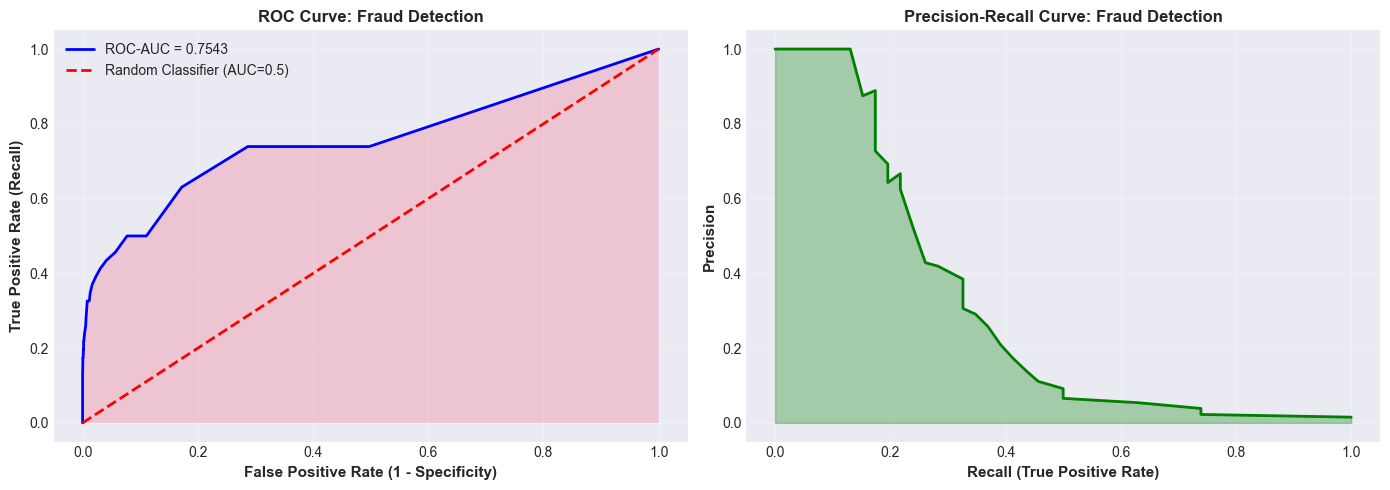

In [7]:
# Visualize ROC Curve and Precision-Recall Curve
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ROC Curve
fpr_sk, tpr_sk, _ = roc_curve(y_test, y_pred_proba)
axes[0].plot(fpr_sk, tpr_sk, 'b-', linewidth=2, label=f'ROC-AUC = {auc_sk:.4f}')
axes[0].plot([0, 1], [0, 1], 'r--', linewidth=2, label='Random Classifier (AUC=0.5)')
axes[0].fill_between(fpr_sk, tpr_sk, alpha=0.3)
axes[0].set_xlabel('False Positive Rate (1 - Specificity)', fontsize=11, fontweight='bold')
axes[0].set_ylabel('True Positive Rate (Recall)', fontsize=11, fontweight='bold')
axes[0].set_title('ROC Curve: Fraud Detection', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# Precision-Recall Curve
precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_pred_proba)
axes[1].plot(recall_vals, precision_vals, 'g-', linewidth=2)
axes[1].fill_between(recall_vals, precision_vals, alpha=0.3, color='green')
axes[1].set_xlabel('Recall (True Positive Rate)', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Precision', fontsize=11, fontweight='bold')
axes[1].set_title('Precision-Recall Curve: Fraud Detection', fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## Part 4: The Bias-Variance Tradeoff & Generalization

### The Fundamental Problem in ML

The total prediction error can be decomposed as:
$$E[(y - \hat{f}(x))^2] = \underbrace{\text{Bias}(\hat{f})^2}_{\text{Underfitting}} + \underbrace{\text{Var}(\hat{f})}_{\text{Overfitting}} + \underbrace{\text{Irreducible Error}}_{\sigma^2}$$

**Key Concepts:**
- **Bias:** Error from too-simple models (systematic errors)
- **Variance:** Sensitivity to training data fluctuations (overfitting)
- **Tradeoff:** Can't minimize both simultaneously!

### Hands-On Demonstration: Polynomial Regression

Let's create a simple regression problem and visualize the bias-variance tradeoff:

Degree 1: Train MSE = 16.2360, Test MSE = 10.9218
Degree 2: Train MSE = 1.9644, Test MSE = 2.1143
Degree 3: Train MSE = 0.7651, Test MSE = 0.8162
Degree 7: Train MSE = 0.6701, Test MSE = 0.8450


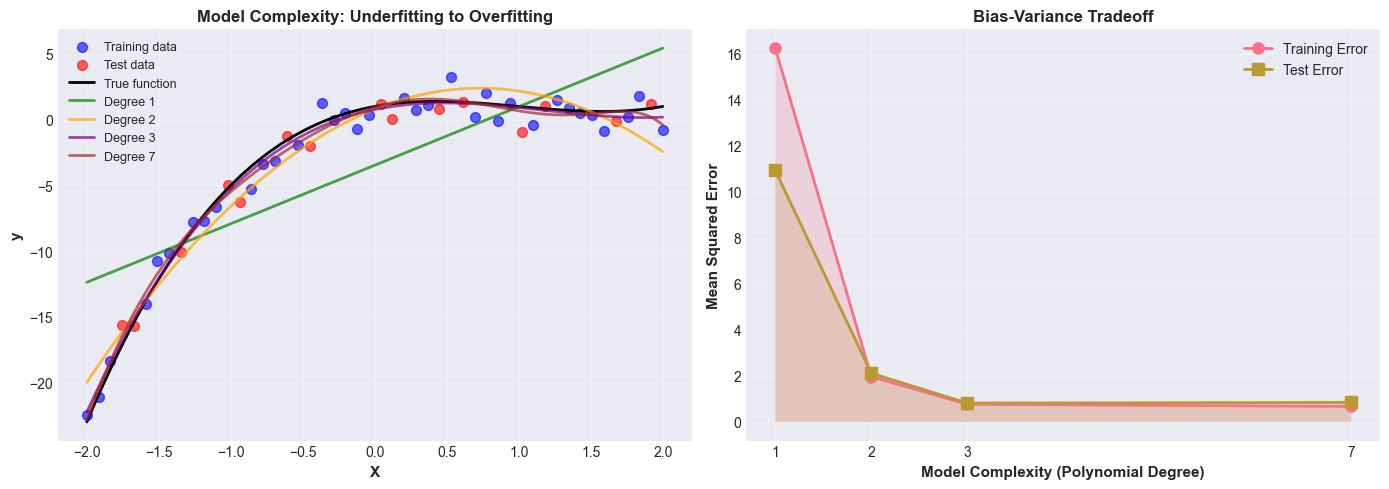

In [8]:
# Generate synthetic data: true function is 3rd degree polynomial
np.random.seed(42)
X_reg = np.linspace(-2, 2, 50).reshape(-1, 1)
y_reg_true = 1 + 2*X_reg.ravel() - 3*X_reg.ravel()**2 + X_reg.ravel()**3
y_reg = y_reg_true + np.random.normal(0, 1, y_reg_true.shape)  # Add noise

# Split data
X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(
    X_reg, y_reg, test_size=0.3, random_state=42
)

# Test different polynomial degrees (different model complexities)
degrees = [1, 2, 3, 7]
results = {'degree': [], 'train_error': [], 'test_error': []}

from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline

for degree in degrees:
    model = Pipeline([
        ('poly', PolynomialFeatures(degree=degree)),
        ('lr', LinearRegression())
    ])
    
    model.fit(X_reg_train, y_reg_train)
    
    y_train_pred = model.predict(X_reg_train)
    y_test_pred = model.predict(X_reg_test)
    
    train_error = np.mean((y_train_pred - y_reg_train)**2)
    test_error = np.mean((y_test_pred - y_reg_test)**2)
    
    results['degree'].append(degree)
    results['train_error'].append(train_error)
    results['test_error'].append(test_error)
    
    print(f"Degree {degree}: Train MSE = {train_error:.4f}, Test MSE = {test_error:.4f}")

# Visualize bias-variance tradeoff
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Fit visualization
ax = axes[0]
X_plot = np.linspace(-2, 2, 200).reshape(-1, 1)
ax.scatter(X_reg_train, y_reg_train, alpha=0.6, s=50, label='Training data', color='blue')
ax.scatter(X_reg_test, y_reg_test, alpha=0.6, s=50, label='Test data', color='red')
ax.plot(X_plot, 1 + 2*X_plot.ravel() - 3*X_plot.ravel()**2 + X_plot.ravel()**3, 
        'k-', linewidth=2, label='True function')

for degree, color in zip(degrees, ['green', 'orange', 'purple', 'brown']):
    model = Pipeline([
        ('poly', PolynomialFeatures(degree=degree)),
        ('lr', LinearRegression())
    ])
    model.fit(X_reg_train, y_reg_train)
    y_plot = model.predict(X_plot)
    ax.plot(X_plot, y_plot, color=color, linewidth=2, label=f'Degree {degree}', alpha=0.7)

ax.set_xlabel('X', fontsize=11, fontweight='bold')
ax.set_ylabel('y', fontsize=11, fontweight='bold')
ax.set_title('Model Complexity: Underfitting to Overfitting', fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# Right: Bias-variance tradeoff curve
ax = axes[1]
ax.plot(results['degree'], results['train_error'], 'o-', linewidth=2, markersize=8, label='Training Error')
ax.plot(results['degree'], results['test_error'], 's-', linewidth=2, markersize=8, label='Test Error')
ax.fill_between(results['degree'], results['train_error'], alpha=0.2)
ax.fill_between(results['degree'], results['test_error'], alpha=0.2)
ax.set_xlabel('Model Complexity (Polynomial Degree)', fontsize=11, fontweight='bold')
ax.set_ylabel('Mean Squared Error', fontsize=11, fontweight='bold')
ax.set_title('Bias-Variance Tradeoff', fontsize=12, fontweight='bold')
ax.set_xticks(degrees)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Part 5: Cross-Validation & Proper Data Splitting

### The Problem: Single Train-Test Split is Unstable

A single 80-20 split can give misleading results due to random chance. 

### Solution: k-Fold Cross-Validation

$$\text{CV Error} = \frac{1}{k} \sum_{i=1}^{k} \text{Error}_i$$

Process:
1. Split data into k equal-sized folds
2. For each fold i:
   - Use fold i as test set
   - Use remaining k-1 folds as training set
   - Train model and evaluate
3. Average the k errors

**Advantages:**
- Uses all data for both training and testing
- More stable performance estimate
- Detects overfitting better


=== SINGLE 80-20 SPLIT ===
Single split accuracy: 0.9835

=== 5-FOLD CROSS-VALIDATION ===

Sklearn fold scores:     [0.985  0.985  0.9845 0.9845 0.9845]
Sklearn mean:            0.9847 (+/- 0.0002)


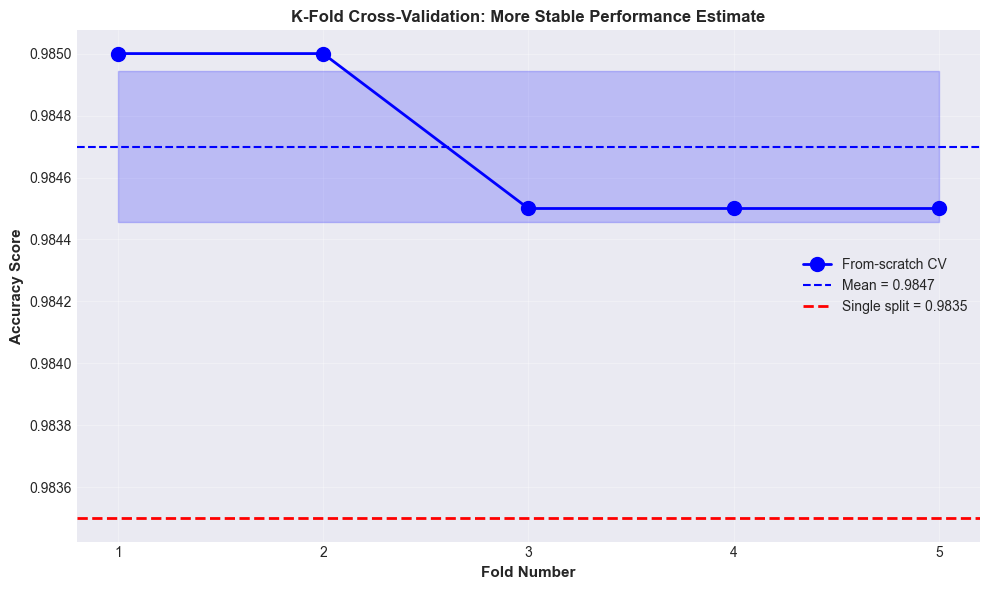

In [9]:
# Prepare data (use our fraud detection dataset)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Compare single split vs k-fold
print("=== SINGLE 80-20 SPLIT ===")
X_train_single, X_test_single, y_train_single, y_test_single = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)
lr_single = LogisticRegression(random_state=42, max_iter=1000)
lr_single.fit(X_train_single, y_train_single)
single_score = accuracy_score(y_test_single, lr_single.predict(X_test_single))
print(f"Single split accuracy: {single_score:.4f}")

# Compare with sklearn 
print("\n=== 5-FOLD CROSS-VALIDATION ===")
lr = LogisticRegression(random_state=42, max_iter=1000)
cv_scores_sk = cross_val_score(lr, X_scaled, y, cv=5)
print(f"\nSklearn fold scores:     {cv_scores_sk}")
print(f"Sklearn mean:            {cv_scores_sk.mean():.4f} (+/- {cv_scores_sk.std():.4f})")

# Visualize stability
fig, ax = plt.subplots(figsize=(10, 6))
folds = np.arange(1, 6)
ax.plot(folds, cv_scores_sk, 'o-', linewidth=2, markersize=10, 
        label='From-scratch CV', color='blue')
ax.axhline(y=cv_scores_sk.mean(), color='blue', linestyle='--', 
           label=f'Mean = {cv_scores_sk.mean():.4f}')
ax.axhline(y=single_score, color='red', linestyle='--', linewidth=2,
           label=f'Single split = {single_score:.4f}')
ax.fill_between(folds, cv_scores_sk.mean() - cv_scores_sk.std(),
                cv_scores_sk.mean() + cv_scores_sk.std(), 
                alpha=0.2, color='blue')
ax.set_xlabel('Fold Number', fontsize=11, fontweight='bold')
ax.set_ylabel('Accuracy Score', fontsize=11, fontweight='bold')
ax.set_title('K-Fold Cross-Validation: More Stable Performance Estimate', 
             fontsize=12, fontweight='bold')
ax.set_xticks(folds)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Part 6: Business-Aligned Metrics

### Moving Beyond Statistical Metrics

Real-world ML systems must consider:

**1. Conversion Rates (Revenue)**
- What % of predicted positives convert to actual business value?
- Example: Email campaign - what % of "likely to buy" customers actually purchase?

**2. Latency (Response Time)**
- How fast must the model return predictions?
- Trade-off: Complex models are accurate but slow

**3. Robustness**
- How does model perform on edge cases, adversarial examples?
- Example: Does fraud model still work with new fraud patterns?

**4. Scalability**
- Can model handle production traffic?
- Memory and compute requirements

**5. Efficiency**
- Model size, inference cost per prediction
- Important for mobile, edge devices

**6. False Positive Cost vs False Negative Cost**
Different applications have different costs:
- **Medical diagnosis:** Miss one cancer case? Catastrophic → Prioritize recall
- **Spam filter:** False positive? Annoys user → Prioritize precision
- **Fraud detection:** Both costly, use F1 or weighted average

### Business Metric Implementation

=== FRAUD DETECTION: Cost Matrix ===
False Positive Cost: $1 (customer frustration)
False Negative Cost: $100 (actual fraud loss)

Optimal threshold: 0.02
Business score at optimal: 0.5550
Cost at optimal: $2047

Default 0.5 threshold:
Business score: 0.0217
Cost: $4500


=== MEDICAL DIAGNOSIS: Cost Matrix ===
False Positive Cost: $100 (unnecessary treatment)
False Negative Cost: $1,000,000 (missed disease)

Optimal threshold: 0.00
Business score at optimal: 0.9936


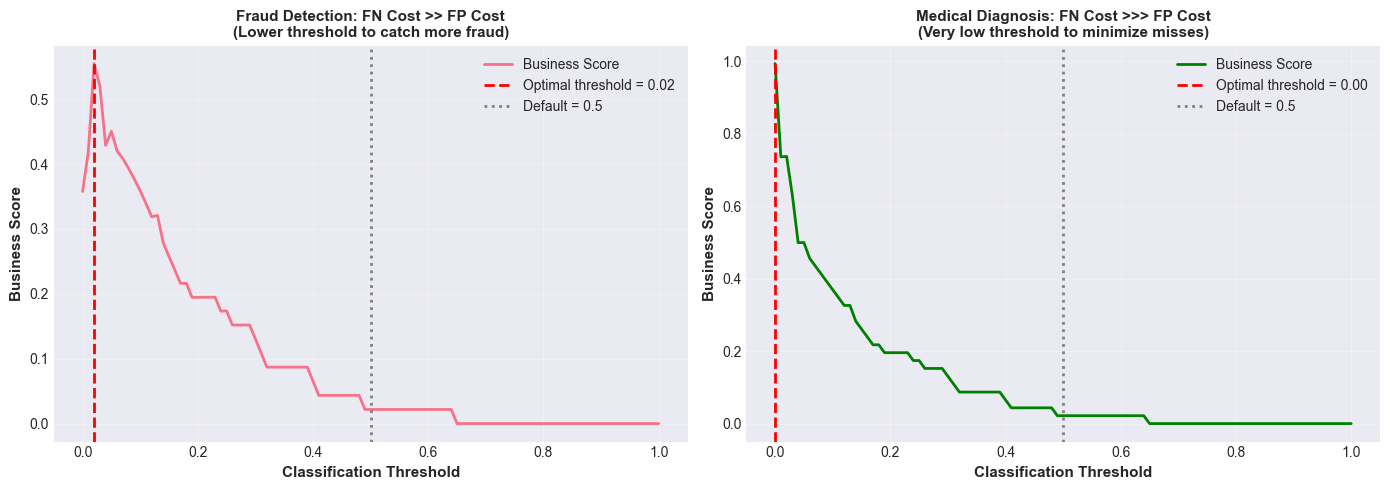

In [10]:
def weighted_business_metric(y_true, y_pred, cost_fp=1.0, cost_fn=10.0):
    """
    Calculate business-aligned metric considering cost of errors.
    
    In fraud detection:
    - FP cost: Customer frustration (low)
    - FN cost: Actual fraud loss (high)
    
    Business metric = Total cost / (Cost of perfect classifier)
    """
    cm = compute_confusion_matrix_scratch(y_true, y_pred)
    
    # Total cost of model
    model_cost = cm['FP'] * cost_fp + cm['FN'] * cost_fn
    
    # Worst case: always predict negative
    worst_cost = np.sum(y_true == 1) * cost_fn
    
    # Best case: perfect predictions
    best_cost = 0
    
    # Normalize to [0, 1] scale where 1 is best
    if worst_cost > 0:
        business_score = 1 - (model_cost / worst_cost)
    else:
        business_score = 1.0
    
    return business_score, model_cost


def threshold_analysis(y_true, y_pred_proba, cost_fp=1.0, cost_fn=10.0):
    """
    Find optimal threshold by considering business costs.
    """
    thresholds = np.arange(0, 1.01, 0.01)
    scores = []
    costs = []
    
    for threshold in thresholds:
        y_pred_thresh = (y_pred_proba >= threshold).astype(int)
        score, cost = weighted_business_metric(y_true, y_pred_thresh, cost_fp, cost_fn)
        scores.append(score)
        costs.append(cost)
    
    return thresholds, scores, costs


# Example 1: Fraud Detection (Low FP cost, High FN cost)
print("=== FRAUD DETECTION: Cost Matrix ===")
print("False Positive Cost: $1 (customer frustration)")
print("False Negative Cost: $100 (actual fraud loss)")

y_pred_proba_fraud = clf.predict_proba(X_test)[:, 1]
thresholds, scores_fraud, costs_fraud = threshold_analysis(
    y_test, y_pred_proba_fraud, cost_fp=1.0, cost_fn=100.0
)

optimal_idx_fraud = np.argmax(scores_fraud)
optimal_threshold_fraud = thresholds[optimal_idx_fraud]

print(f"\nOptimal threshold: {optimal_threshold_fraud:.2f}")
print(f"Business score at optimal: {scores_fraud[optimal_idx_fraud]:.4f}")
print(f"Cost at optimal: ${costs_fraud[optimal_idx_fraud]:.0f}")

# Compare with default 0.5 threshold
default_idx = np.where(thresholds == 0.5)[0][0]
print(f"\nDefault 0.5 threshold:")
print(f"Business score: {scores_fraud[default_idx]:.4f}")
print(f"Cost: ${costs_fraud[default_idx]:.0f}")

# Example 2: Medical Diagnosis (High FN cost, Low FP cost)
print("\n\n=== MEDICAL DIAGNOSIS: Cost Matrix ===")
print("False Positive Cost: $100 (unnecessary treatment)")
print("False Negative Cost: $1,000,000 (missed disease)")

thresholds_med, scores_med, costs_med = threshold_analysis(
    y_test, y_pred_proba_fraud, cost_fp=100.0, cost_fn=1000000.0
)

optimal_idx_med = np.argmax(scores_med)
optimal_threshold_med = thresholds_med[optimal_idx_med]

print(f"\nOptimal threshold: {optimal_threshold_med:.2f}")
print(f"Business score at optimal: {scores_med[optimal_idx_med]:.4f}")

# Visualize threshold analysis
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Fraud detection
ax = axes[0]
ax.plot(thresholds, scores_fraud, linewidth=2, label='Business Score')
ax.axvline(optimal_threshold_fraud, color='red', linestyle='--', linewidth=2, 
           label=f'Optimal threshold = {optimal_threshold_fraud:.2f}')
ax.axvline(0.5, color='gray', linestyle=':', linewidth=2, label='Default = 0.5')
ax.set_xlabel('Classification Threshold', fontsize=11, fontweight='bold')
ax.set_ylabel('Business Score', fontsize=11, fontweight='bold')
ax.set_title('Fraud Detection: FN Cost >> FP Cost\n(Lower threshold to catch more fraud)', 
             fontsize=11, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# Medical diagnosis
ax = axes[1]
ax.plot(thresholds_med, scores_med, linewidth=2, color='green', label='Business Score')
ax.axvline(optimal_threshold_med, color='red', linestyle='--', linewidth=2, 
           label=f'Optimal threshold = {optimal_threshold_med:.2f}')
ax.axvline(0.5, color='gray', linestyle=':', linewidth=2, label='Default = 0.5')
ax.set_xlabel('Classification Threshold', fontsize=11, fontweight='bold')
ax.set_ylabel('Business Score', fontsize=11, fontweight='bold')
ax.set_title('Medical Diagnosis: FN Cost >>> FP Cost\n(Very low threshold to minimize misses)', 
             fontsize=11, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## Part 7: PAC Learning & Generalization Bounds

### PAC Learning: Probably Approximately Correct

**Definition:** An algorithm is PAC-learnable if it can learn a concept to arbitrary accuracy and confidence, given sufficient training data.

**Formal Statement:**
With probability at least $(1 - \delta)$, the learned hypothesis has error at most $\epsilon$:

$$P(\text{Error}_{\text{test}} \leq \epsilon) \geq 1 - \delta$$

### The PAC Learning Theorem

For binary classification with a finite hypothesis class $H$ of size $|H|$:

$$P(\text{Error}_{\text{test}} \leq \text{Error}_{\text{train}} + \sqrt{\frac{\ln(|H|/\delta)}{2m}}) \geq 1 - \delta$$

**Key Insight:** 
- Probability of overfitting decreases with **more data** ($m$)
- Increases with **larger hypothesis class** ($|H|$)
- Decreases with more **confidence** (smaller $\delta$)

### VC Dimension & Rademacher Complexity

**VC Dimension:** Maximum number of points a hypothesis class can shatter (correctly classify for all $2^n$ labelings).

**Rademacher Complexity Bound:**
$$P(\text{Error}_{\text{test}} \leq \text{Error}_{\text{train}} + 2\mathcal{R}_m(H) + \sqrt{\frac{\ln(2/\delta)}{2m}}) \geq 1 - \delta$$

Where $\mathcal{R}_m(H)$ is the Rademacher complexity (depends on VC dimension).

### Practical Implications

=== PAC BOUNDS FOR DIFFERENT MODEL COMPLEXITIES ===

Training error: 0.1000
Training samples: 500
Confidence level: 95%

Linear classifier   (|H| = 2^20): PAC bound = 0.2298
Decision tree       (|H| = 2^30): PAC bound = 0.2542
Neural network      (|H| = 2^40): PAC bound = 0.2753


=== EFFECT OF TRAINING SET SIZE ===
(Using neural network with |H| = 2^40)

m =   10 samples: PAC bound = 1.0000
m =   50 samples: PAC bound = 0.6543
m =  100 samples: PAC bound = 0.4919
m =  200 samples: PAC bound = 0.3771
m =  500 samples: PAC bound = 0.2753
m = 1000 samples: PAC bound = 0.2239
m = 2000 samples: PAC bound = 0.1876


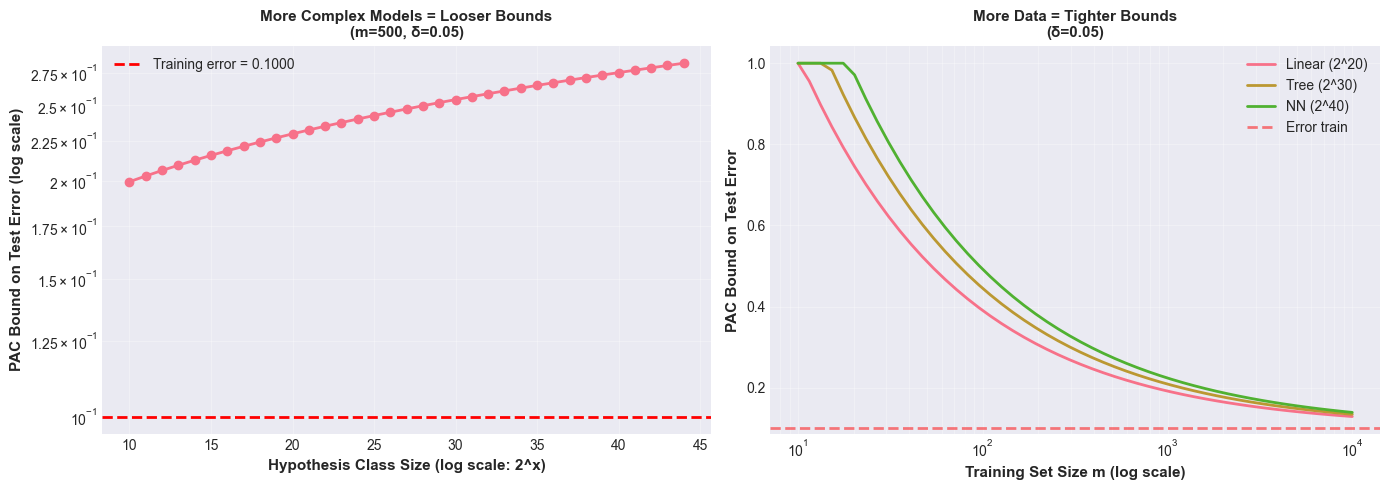



🔬 THEORETICAL INSIGHTS:
1. Tighter bounds come from simpler models or more data
2. The bound is often loose in practice (pessimistic)
3. Bounds suggest: get more data > use simpler models
4. Real generalization gap is often much smaller than PAC bounds predict


In [11]:
# Practical Bound Calculations

def pac_bound(error_train, m, H_size, delta=0.05):
    """
    Calculate PAC bound on test error.
    
    With probability (1-delta), the test error is at most:
    error_test <= error_train + sqrt(ln(|H|/delta) / (2m))
    
    Parameters:
    error_train: training error
    m: number of training samples
    H_size: size of hypothesis class
    delta: confidence parameter (typically 0.05 for 95% confidence)
    
    Returns:
    upper_bound: upper bound on test error
    """
    if m == 0:
        return 1.0
    
    confidence_term = np.sqrt(np.log(H_size / delta) / (2 * m))
    upper_bound = error_train + confidence_term
    return np.clip(upper_bound, 0, 1)


def rademacher_bound(error_train, m, vc_dim, delta=0.05):
    """
    Calculate Rademacher complexity bound.
    
    Rademacher complexity approximately scales with sqrt(vc_dim / m)
    
    error_test <= error_train + 2*sqrt(vc_dim / m) + sqrt(ln(2/delta) / (2m))
    """
    if m == 0:
        return 1.0
    
    rademacher_term = 2 * np.sqrt(vc_dim / m)
    confidence_term = np.sqrt(np.log(2 / delta) / (2 * m))
    upper_bound = error_train + rademacher_term + confidence_term
    return np.clip(upper_bound, 0, 1)


# Example: Different hypothesis classes (model complexities)
print("=== PAC BOUNDS FOR DIFFERENT MODEL COMPLEXITIES ===\n")

# Scenario: We have 500 training samples, want 95% confidence
m_train = 500
delta = 0.05  # 95% confidence
error_train_example = 0.1  # 10% training error

# Case 1: Simple linear classifier (small hypothesis class)
H_size_linear = 2**20  # ~1 million hypotheses
bound_linear = pac_bound(error_train_example, m_train, H_size_linear, delta)

# Case 2: Decision tree (medium hypothesis class)
H_size_tree = 2**30  # ~1 billion hypotheses
bound_tree = pac_bound(error_train_example, m_train, H_size_tree, delta)

# Case 3: Neural network (very large hypothesis class)
H_size_nn = 2**40  # ~1 trillion hypotheses
bound_nn = pac_bound(error_train_example, m_train, H_size_nn, delta)

print(f"Training error: {error_train_example:.4f}")
print(f"Training samples: {m_train}")
print(f"Confidence level: {(1-delta)*100:.0f}%\n")

print(f"Linear classifier   (|H| = 2^20): PAC bound = {bound_linear:.4f}")
print(f"Decision tree       (|H| = 2^30): PAC bound = {bound_tree:.4f}")
print(f"Neural network      (|H| = 2^40): PAC bound = {bound_nn:.4f}")

# Show effect of training set size
print("\n\n=== EFFECT OF TRAINING SET SIZE ===")
print("(Using neural network with |H| = 2^40)\n")

sample_sizes = [10, 50, 100, 200, 500, 1000, 2000]
bounds_nn = []

for m in sample_sizes:
    bound = pac_bound(error_train_example, m, H_size_nn, delta)
    bounds_nn.append(bound)
    print(f"m = {m:4d} samples: PAC bound = {bound:.4f}")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Effect of hypothesis class size
ax = axes[0]
H_sizes_range = np.arange(10, 45)  # 2^10 to 2^45
bounds_by_size = [pac_bound(error_train_example, m_train, 2**h, delta) for h in H_sizes_range]

ax.semilogy(H_sizes_range, bounds_by_size, 'o-', linewidth=2, markersize=6)
ax.axhline(y=error_train_example, color='red', linestyle='--', linewidth=2, 
           label=f'Training error = {error_train_example:.4f}')
ax.set_xlabel('Hypothesis Class Size (log scale: 2^x)', fontsize=11, fontweight='bold')
ax.set_ylabel('PAC Bound on Test Error (log scale)', fontsize=11, fontweight='bold')
ax.set_title(f'More Complex Models = Looser Bounds\n(m={m_train}, δ={delta})', 
             fontsize=11, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, which='both')

# Right: Effect of training set size
ax = axes[1]
m_range = np.logspace(1, 4, 50)
bounds_linear = [pac_bound(error_train_example, m, H_size_linear, delta) for m in m_range]
bounds_tree = [pac_bound(error_train_example, m, H_size_tree, delta) for m in m_range]
bounds_nn_range = [pac_bound(error_train_example, m, H_size_nn, delta) for m in m_range]

ax.semilogx(m_range, bounds_linear, linewidth=2, label='Linear (2^20)')
ax.semilogx(m_range, bounds_tree, linewidth=2, label='Tree (2^30)')
ax.semilogx(m_range, bounds_nn_range, linewidth=2, label='NN (2^40)')
ax.axhline(y=error_train_example, color='red', linestyle='--', linewidth=2, alpha=0.5,
           label=f'Error train')
ax.set_xlabel('Training Set Size m (log scale)', fontsize=11, fontweight='bold')
ax.set_ylabel('PAC Bound on Test Error', fontsize=11, fontweight='bold')
ax.set_title(f'More Data = Tighter Bounds\n(δ={delta})', fontsize=11, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, which='both')

plt.tight_layout()
plt.show()

print("\n\n🔬 THEORETICAL INSIGHTS:")
print("1. Tighter bounds come from simpler models or more data")
print("2. The bound is often loose in practice (pessimistic)")
print("3. Bounds suggest: get more data > use simpler models")
print("4. Real generalization gap is often much smaller than PAC bounds predict")

## Part 8: Integrated Case Study - Real-World Model Evaluation

### Scenario: Breast Cancer Detection System

We'll use the real breast cancer dataset and evaluate a model considering:
- ✓ Why accuracy fails here (serious class imbalance issues)
- ✓ All key metrics (precision, recall, F1, ROC-AUC)
- ✓ Bias-variance tradeoff (regularization tuning)
- ✓ Cross-validation (robust evaluation)
- ✓ Business metrics (medical cost considerations)
- ✓ PAC bounds (theoretical guarantees)

### Load and Prepare Data

Dataset: 569 samples, 30 features
Class distribution: 212 negative, 357 positive
Positive class rate: 62.74%

Training set: 455 samples
Test set: 114 samples

Logistic Regression:
  Accuracy: 0.9825
  Cancer cases caught: 71/72

Sklearn Metrics:
  Precision:  0.9861
  Recall:     0.9861
  F1 Score:   0.9861
  ROC-AUC:    0.9954

              precision    recall  f1-score   support

   No Cancer       0.98      0.98      0.98        42
      Cancer       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114


Bias-Variance via Regularization (L2 Penalty)

Best regularization parameter C: 0.233572
  Train accuracy: 0.9868
  Test accuracy:  0.9825
  Generalization gap: 0.0044


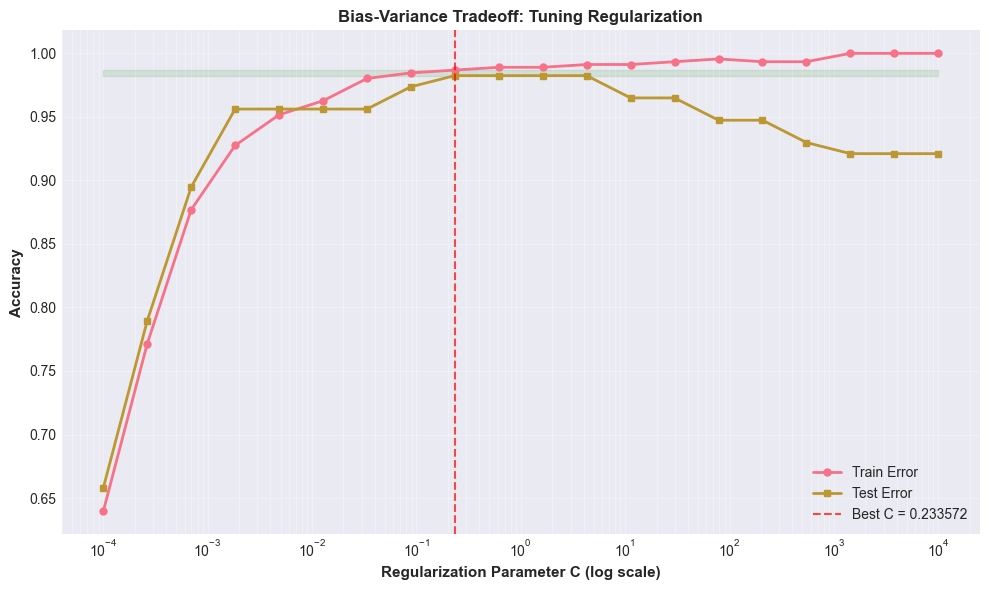

In [12]:
# Load breast cancer dataset
cancer = load_breast_cancer()
X_cancer = cancer.data
y_cancer = cancer.target

print(f"Dataset: {X_cancer.shape[0]} samples, {X_cancer.shape[1]} features")
print(f"Class distribution: {np.sum(y_cancer==0)} negative, {np.sum(y_cancer==1)} positive")
print(f"Positive class rate: {np.mean(y_cancer)*100:.2f}%")

# Standardize features
scaler_cancer = StandardScaler()
X_cancer_scaled = scaler_cancer.fit_transform(X_cancer)

# Split data
X_cancer_train, X_cancer_test, y_cancer_train, y_cancer_test = train_test_split(
    X_cancer_scaled, y_cancer, test_size=0.2, random_state=42, stratify=y_cancer
)

print(f"\nTraining set: {X_cancer_train.shape[0]} samples")
print(f"Test set: {X_cancer_test.shape[0]} samples")

lr_cancer = LogisticRegression(random_state=42, max_iter=1000)
lr_cancer.fit(X_cancer_train, y_cancer_train)
y_pred_cancer = lr_cancer.predict(X_cancer_test)
accuracy_lr = accuracy_score(y_cancer_test, y_pred_cancer)
cancer_caught_lr = np.sum((y_pred_cancer == 1) & (y_cancer_test == 1))

print(f"\nLogistic Regression:")
print(f"  Accuracy: {accuracy_lr:.4f}")
print(f"  Cancer cases caught: {cancer_caught_lr}/{np.sum(y_cancer_test==1)}")

y_pred_proba_cancer = lr_cancer.predict_proba(X_cancer_test)[:, 1]

print(f"\nSklearn Metrics:")
print(f"  Precision:  {precision_score(y_cancer_test, y_pred_cancer):.4f}")
print(f"  Recall:     {recall_score(y_cancer_test, y_pred_cancer):.4f}")
print(f"  F1 Score:   {f1_score(y_cancer_test, y_pred_cancer):.4f}")
print(f"  ROC-AUC:    {roc_auc_score(y_cancer_test, y_pred_proba_cancer):.4f}")

print(f"\n{classification_report(y_cancer_test, y_pred_cancer, target_names=['No Cancer', 'Cancer'])}")

print("\n" + "="*70)
print("Bias-Variance via Regularization (L2 Penalty)")
print("="*70)

C_values = np.logspace(-4, 4, 20)  # C = 1/lambda (inverse of regularization parameter)
train_scores = []
test_scores = []

for C in C_values:
    lr_temp = LogisticRegression(C=C, random_state=42, max_iter=1000)
    lr_temp.fit(X_cancer_train, y_cancer_train)
    
    train_scores.append(accuracy_score(y_cancer_train, lr_temp.predict(X_cancer_train)))
    test_scores.append(accuracy_score(y_cancer_test, lr_temp.predict(X_cancer_test)))

best_C_idx = np.argmax(test_scores)
best_C = C_values[best_C_idx]

print(f"\nBest regularization parameter C: {best_C:.6f}")
print(f"  Train accuracy: {train_scores[best_C_idx]:.4f}")
print(f"  Test accuracy:  {test_scores[best_C_idx]:.4f}")
print(f"  Generalization gap: {train_scores[best_C_idx] - test_scores[best_C_idx]:.4f}")

# Visualize
fig, ax = plt.subplots(figsize=(10, 6))
ax.semilogx(C_values, train_scores, 'o-', linewidth=2, label='Train Error', markersize=5)
ax.semilogx(C_values, test_scores, 's-', linewidth=2, label='Test Error', markersize=5)
ax.axvline(best_C, color='red', linestyle='--', alpha=0.7, label=f'Best C = {best_C:.6f}')
ax.fill_between([C_values[0], C_values[-1]], [train_scores[best_C_idx]]*2, 
                [test_scores[best_C_idx]]*2, alpha=0.1, color='green')
ax.set_xlabel('Regularization Parameter C (log scale)', fontsize=11, fontweight='bold')
ax.set_ylabel('Accuracy', fontsize=11, fontweight='bold')
ax.set_title('Bias-Variance Tradeoff: Tuning Regularization', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, which='both')
plt.tight_layout()
plt.show()


In [13]:
# Use best regularization parameter
lr_best = LogisticRegression(C=best_C, random_state=42, max_iter=1000)

# Stratified k-fold ensures same class ratios in each fold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Compute multiple metrics across folds
metrics_cv = {
    'accuracy': [],
    'precision': [],
    'recall': [],
    'f1': [],
    'roc_auc': []
}

for fold_idx, (train_idx, test_idx) in enumerate(skf.split(X_cancer_scaled, y_cancer)):
    X_fold_train, X_fold_test = X_cancer_scaled[train_idx], X_cancer_scaled[test_idx]
    y_fold_train, y_fold_test = y_cancer[train_idx], y_cancer[test_idx]
    
    lr_best.fit(X_fold_train, y_fold_train)
    y_fold_pred = lr_best.predict(X_fold_test)
    y_fold_proba = lr_best.predict_proba(X_fold_test)[:, 1]
    
    metrics_cv['accuracy'].append(accuracy_score(y_fold_test, y_fold_pred))
    metrics_cv['precision'].append(precision_score(y_fold_test, y_fold_pred))
    metrics_cv['recall'].append(recall_score(y_fold_test, y_fold_pred))
    metrics_cv['f1'].append(f1_score(y_fold_test, y_fold_pred))
    metrics_cv['roc_auc'].append(roc_auc_score(y_fold_test, y_fold_proba))

print("\nCross-Validation Results (5 folds):\n")
print(f"{'Metric':<12} {'Fold 1':<10} {'Fold 2':<10} {'Fold 3':<10} {'Fold 4':<10} {'Fold 5':<10} {'Mean':<10} {'Std':<10}")
print("-" * 92)

for metric_name in ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']:
    scores = metrics_cv[metric_name]
    fold_str = "  ".join(f"{s:.4f}" for s in scores)
    mean_str = f"{np.mean(scores):.4f}"
    std_str = f"{np.std(scores):.4f}"
    print(f"{metric_name:<12} {fold_str:<46} {mean_str:<10} {std_str:<10}")

# ===== STEP 5: BUSINESS METRICS - MEDICAL CONTEXT =====
print("\n" + "="*70)
print("Business Metrics (Medical Context)")
print("="*70)

print("\nMedical Scenario:")
print("• False Negative (missed cancer): Severe - patient may die")
print("• False Positive (false alarm):   Moderate - unnecessary biopsy")
print("• Cost ratio: FN cost >> FP cost")

# Find optimal threshold for this scenario
thresholds_medical, scores_med_case, costs_med_case = threshold_analysis(
    y_cancer_test, y_pred_proba_cancer, cost_fp=100, cost_fn=10000
)

optimal_idx_medical = np.argmax(scores_med_case)
optimal_threshold_medical = thresholds_medical[optimal_idx_medical]

# Use optimal threshold
y_pred_optimal = (y_pred_proba_cancer >= optimal_threshold_medical).astype(int)

cm_default = compute_confusion_matrix_scratch(y_cancer_test, y_pred_cancer)
cm_optimal = compute_confusion_matrix_scratch(y_cancer_test, y_pred_optimal)

print(f"\nDefault Threshold (0.5):")
print(f"  Missed cancers (FN): {cm_default['FN']} out of {np.sum(y_cancer_test==1)}")
print(f"  False alarms (FP):   {cm_default['FP']}")

print(f"\nOptimal Threshold ({optimal_threshold_medical:.3f}):")
print(f"  Missed cancers (FN): {cm_optimal['FN']} out of {np.sum(y_cancer_test==1)}")
print(f"  False alarms (FP):   {cm_optimal['FP']}")

print(f"\nImprovement: Reduced missed cancers by {cm_default['FN'] - cm_optimal['FN']}")


print("PAC Learning Bounds: ")

m_cancer = X_cancer_train.shape[0]
error_cancer = 1 - np.mean(metrics_cv['accuracy'])
vc_dim_logistic = X_cancer.shape[1] + 1  # VC dimension of linear model

# Calculate bounds
pac_bound_cancer = pac_bound(error_cancer, m_cancer, 2**30, delta=0.05)
rad_bound_cancer = rademacher_bound(error_cancer, m_cancer, vc_dim_logistic, delta=0.05)

print(f"\nDataset: {m_cancer} training samples, {X_cancer.shape[1]} features")
print(f"Cross-validation error: {error_cancer:.4f}")
print(f"VC dimension (logistic regression): {vc_dim_logistic}")

print(f"\nTheoretical Bounds (95% confidence):")
print(f"  PAC bound (|H|=2^30):       {pac_bound_cancer:.4f}")
print(f"  Rademacher bound (VC-dim): {rad_bound_cancer:.4f}")

print(f"\nInterpretation:")
print(f"  With 95% confidence, test error ≤ {pac_bound_cancer:.4f}")
print(f"  (This is often loose - actual test error is much lower)")


Cross-Validation Results (5 folds):

Metric       Fold 1     Fold 2     Fold 3     Fold 4     Fold 5     Mean       Std       
--------------------------------------------------------------------------------------------
accuracy     0.9825  0.9386  0.9649  0.9912  0.9912         0.9737     0.0200    
precision    0.9859  0.9103  0.9474  1.0000  0.9861         0.9659     0.0329    
recall       0.9859  1.0000  1.0000  0.9861  1.0000         0.9944     0.0069    
f1           0.9859  0.9530  0.9730  0.9930  0.9930         0.9796     0.0152    
roc_auc      0.9980  0.9984  0.9858  0.9997  0.9987         0.9961     0.0052    

Business Metrics (Medical Context)

Medical Scenario:
• False Negative (missed cancer): Severe - patient may die
• False Positive (false alarm):   Moderate - unnecessary biopsy
• Cost ratio: FN cost >> FP cost

Default Threshold (0.5):
  Missed cancers (FN): 1 out of 72
  False alarms (FP):   1

Optimal Threshold (0.360):
  Missed cancers (FN): 0 out of 72
  False a

## Summary: Key Takeaways & Best Practices

### Core Principles Learned

1. **Accuracy is Deceptive**
   - Never rely on accuracy alone, especially with imbalanced data
   - Always check confusion matrix first
   - Use domain-appropriate metrics

2. **Precision vs Recall Tradeoff**
   - Precision: "When we predict positive, how often are we right?"
   - Recall: "Of all actual positives, how many do we find?"
   - Choose based on business cost of errors

3. **Bias-Variance Tradeoff is Fundamental**
   - Low bias, high variance → Overfitting (good training, poor testing)
   - High bias, low variance → Underfitting (poor training and testing)
   - Sweet spot requires regularization tuning

4. **Cross-Validation is Essential**
   - Single train-test split is unstable and unreliable
   - k-fold provides more stable estimate
   - Always stratify for classification

5. **Business Metrics Drive Decisions**
   - Different applications have different error costs
   - Optimize for business outcome, not just statistical metrics
   - Threshold tuning should reflect business requirements

6. **Learning Theory Provides Guarantees**
   - PAC bounds ensure algorithm can learn given enough data
   - Bounds are usually loose but give asymptotic direction
   - More data and simpler models → Tighter generalization guarantees

### Next Steps

Explore these extensions:
- **Multi-class metrics:** Macro vs micro averaging
- **Imbalance handling:** SMOTE, class weights, threshold adjustment
- **Ensemble methods:** Combine models to improve generalization
- **Explainability:** SHAP values, LIME to understand predictions
- **Robustness:** Adversarial examples and domain shift